# ResNet18 — Task-Specific Adapters
Bottleneck CNN adapters inserted after each residual stage; backbone frozen.

In [1]:
import os

os.chdir("..")  
print(os.getcwd())

/Users/peter/Documents/MDS_UBC/DATA_586/food_classification


In [2]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.models import ResNet18_Weights

from helpers import (
    get_food101_loaders, run_training, plot_results, count_trainable_params
)

In [3]:
class CNNAdapter(nn.Module):
    """Lightweight bottleneck residual adapter."""
    def __init__(self, channels: int, reduction_factor: int = 8):
        super().__init__()
        bottleneck = channels // reduction_factor
        self.adapter = nn.Sequential(
            nn.Conv2d(channels, bottleneck, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(bottleneck, channels, kernel_size=1),
        )

    def forward(self, x):
        return x + self.adapter(x)


class ResNetWithAdapters(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.model = backbone
        self.adapters = nn.ModuleDict({
            "layer1": CNNAdapter(64),
            "layer2": CNNAdapter(128),
            "layer3": CNNAdapter(256),
            "layer4": CNNAdapter(512),
        })

    def forward(self, x):
        x = self.model.conv1(x)
        x = self.model.bn1(x)
        x = self.model.relu(x)
        x = self.model.maxpool(x)

        for stage in ("layer1", "layer2", "layer3", "layer4"):
            x = getattr(self.model, stage)(x)
            x = self.adapters[stage](x)

        x = self.model.avgpool(x)
        x = torch.flatten(x, 1)
        return self.model.fc(x)

In [4]:
weights   = ResNet18_Weights.DEFAULT
transform = weights.transforms()

train_loader, val_loader = get_food101_loaders(transform, batch_size=256, num_workers=8)

backbone = models.resnet18(weights=weights)
model    = ResNetWithAdapters(backbone)

# Freeze backbone
for param in model.model.parameters():
    param.requires_grad = False

# Replace & unfreeze head
model.model.fc = nn.Linear(model.model.fc.in_features, 101)
for param in model.model.fc.parameters():
    param.requires_grad = True

# Unfreeze adapters
for param in model.adapters.parameters():
    param.requires_grad = True

print(f"Trainable params: {count_trainable_params(model):,}")

Trainable params: 139,933


In [5]:
model, train_losses, val_losses, train_accs, val_accs = run_training(
    model=model,
    model_name="resnet18_task_specific_adapter",
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    epochs=8,
    lr=1e-3,
)

[resnet18_task_specific_adapter] Final checkpoint found — loading metrics for plotting.


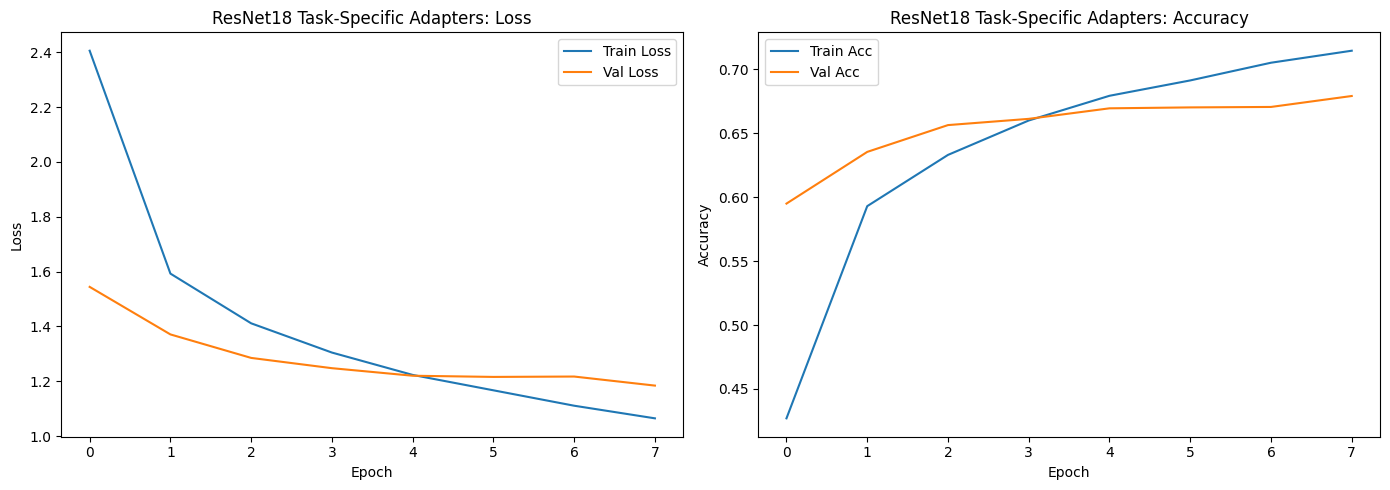

In [6]:
plot_results(train_losses, val_losses, train_accs, val_accs, "ResNet18 Task-Specific Adapters")